## Part 1 : Constructing Variables

In [2]:
# Part 1 : Constructing Variables

import pandas as pd 
import numpy as np 
import matplotlib # Importing the pyplot module for plotting
from matplotlib import pyplot as plt 
import operator
import statsmodels.api as sm 
from tqdm import tqdm

SP500 = pd.read_csv('SP500_2022.csv')
Benchmark = pd.read_csv('Benchmark2022.csv' )
Data = pd.read_csv('Data2022.csv')

Data['date'] = pd.to_datetime(Data['date'].astype(str), format='%Y%m%d') # Convert date to datetime format
Data['date'] = Data['date'].apply(lambda x:x.strftime('%Y%m'))
Data['date'] = Data['date'].astype(int) # Convert date to integer

Date_Unique = sorted(Data['date'].unique()) # create date index
Gvkey_Unique = sorted(Data['gvkey'].unique()) # create stock identifier index
idx_t_start = Date_Unique.index(197001) # starting date of the backtesting
idx_t_end = Date_Unique.index(202212) # ending date of the backtesting
Date_Unique = Date_Unique[idx_t_start: idx_t_end+1] # Slice the date list for the backtesting period

# Loop through each unique date and collect firm data
list_firm_date = []
for idx_date in tqdm(Date_Unique):
    list_firm_date.append(Data[Data['date'].isin([idx_date])].sort_values(
        'gvkey', inplace=False).reset_index(drop=True))

100%|████████████████████████████████████████| 636/636 [00:01<00:00, 580.77it/s]


### Functions Constructing Variables

In [4]:
# Makes sure we use only point-in-time data, no look-ahead bias
Factor_SP500 = [] # Whether the firm is a member of SP500
Factor_HL1M = [] # Price Momentum
Factor_MV = [] # Market Cap
Factor_BM = [] # Book to Price
Factor_AdjPrice = [] # Adjusted Closing Price Preem
Factor_RET = [] # Monthly Return, this is also the dependent variable

for idx_t in tqdm(Date_Unique):
    df_firm = list_firm_date[Date_Unique.index(idx_t)].copy(deep=True)
    
    # Construct the signal for each factor
    
    # SP500 Indicator: member==1, nonmember==0;
    Factor_SP500.append(df_firm[['sp500', 'gvkey']])
    
    df_firm['MV'] = np.log(df_firm['cshoq'] * 1000000 * df_firm['prccm'])
    Factor_MV.append(df_firm[['MV', 'gvkey']]) # Log Market Cap
    
    df_firm = df_firm.drop(['MV'], axis=1)
    
    df_firm['BM'] = df_firm['ceqq']*1000000/(df_firm['cshoq']*1000000*df_firm['prccm'])
    Factor_BM.append(df_firm[['BM', 'gvkey']]) # Book to Price
    df_firm = df_firm.drop(['BM'], axis=1)
    
    df_firm['HL1M'] = (df_firm['prchm']-df_firm['prccm'])/(df_firm['prccm']-
                                                           df_firm['prclm'])
    Factor_HL1M.append(df_firm[['HL1M', 'gvkey']]) # 1M Price high-1M Price Low
    df_firm = df_firm.drop(['HL1M'], axis=1)
    
    Factor_AdjPrice.append(df_firm[['prccm', 'gvkey']]) # Adjusted Closing Price
    
    Factor_RET.append(df_firm[['trt1m', 'gvkey']]) # Monthly Return

 11%|████▌                                    | 71/636 [00:00<00:00, 707.48it/s]/Users/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
 24%|█████████▍                              | 151/636 [00:00<00:00, 758.94it/s]/Users/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in lo

## Part 2 : Sorting

In [6]:
def portfolio_sort(Factor, Factor_RET, Factor_SP500, Quantile):
    RET_Sort_top = []
    RET_Sort_bottom = []
    Factor_Sort = []
    Qspread = []
    
    # Sort portfolio
    for idx_t in tqdm(range(len(Date_Unique)-1)):
        f = Factor[idx_t] # Get the factor data for the current time period
        col_name = f.columns[0]
        ret_sp500 = Factor_RET[idx_t + 1] # Get the return data for the next time period (t+1)
        sp500 = Factor_SP500[idx_t]['sp500'].replace(0, np.nan)
        
        f_sp500 = f[sp500.isnull().values==False].copy(deep=True) # Filter out entries where the SP500 data is missing
        tmp = pd.merge(f_sp500, ret_sp500, on='gvkey', how='outer')
        tmp.dropna(axis='index', how='any', inplace=True)
        tmp = tmp.sort_values(by=[col_name], ascending=False)
        f_sp500 = tmp[[col_name, 'gvkey']].reset_index(drop=True).copy(deep=True)
        ret_sp500 = tmp[['trt1m', 'gvkey']].reset_index(drop=True).copy(deep=True)
        
        if idx_t==0: # no first observation since the portfolio starts at time t+1
            RET_Sort_top.append(np.nan)
            RET_Sort_bottom.append(np.nan)
            Factor_Sort.append(np.nan)
        
        idx_quantile = np.ceil(len(ret_sp500)/Quantile) # Calculate the index for the quantile split
        top = ret_sp500.loc[0:idx_quantile-1].copy(deep=True) # Select the top quantile of returns
        bottom = ret_sp500.loc[(Quantile-1)*idx_quantile:].copy(deep=True) # Select the bottom quantile of returns
        RET_Sort_top.append(top)
        RET_Sort_bottom.append(bottom)
        Factor_Sort.append(f_sp500)

    # Calculate the spread between top and bottom quantiles of returns
    for idx in range(len(RET_Sort_top)):
        if idx == 0:
            Qspread.append(np. nan)
        elif len(RET_Sort_top[idx]) == 0:
            Qspread.append(np.nan)
        else:
            Qspread.append(np.nanmean(RET_Sort_top[idx]['trt1m'])
                           - np.nanmean(RET_Sort_bottom[idx]['trt1m']) )
    return RET_Sort_top, RET_Sort_bottom, Factor_Sort, Qspread

In [7]:
Quantile = 5; # Set the number of quantiles for sorting the portfolio

# Call the portfolio_sort function for the HL1M factor
HL1M_RET_Sort_top, HL1M_RET_Sort_bottom, HL1M_Factor_Sort,HL1M_Qspread=portfolio_sort(
    Factor_HL1M, Factor_RET, Factor_SP500, Quantile)

MV_RET_Sort_top, MV_RET_Sort_bottom, MV_Factor_Sort, MV_Qspread=portfolio_sort(
    Factor_MV, Factor_RET, Factor_SP500, Quantile)

BM_RET_Sort_top, BM_RET_Sort_bottom, BM_Factor_Sort, BM_Qspread=portfolio_sort(
    Factor_BM, Factor_RET, Factor_SP500, Quantile)

100%|████████████████████████████████████████| 635/635 [00:00<00:00, 789.02it/s]


# Question 1

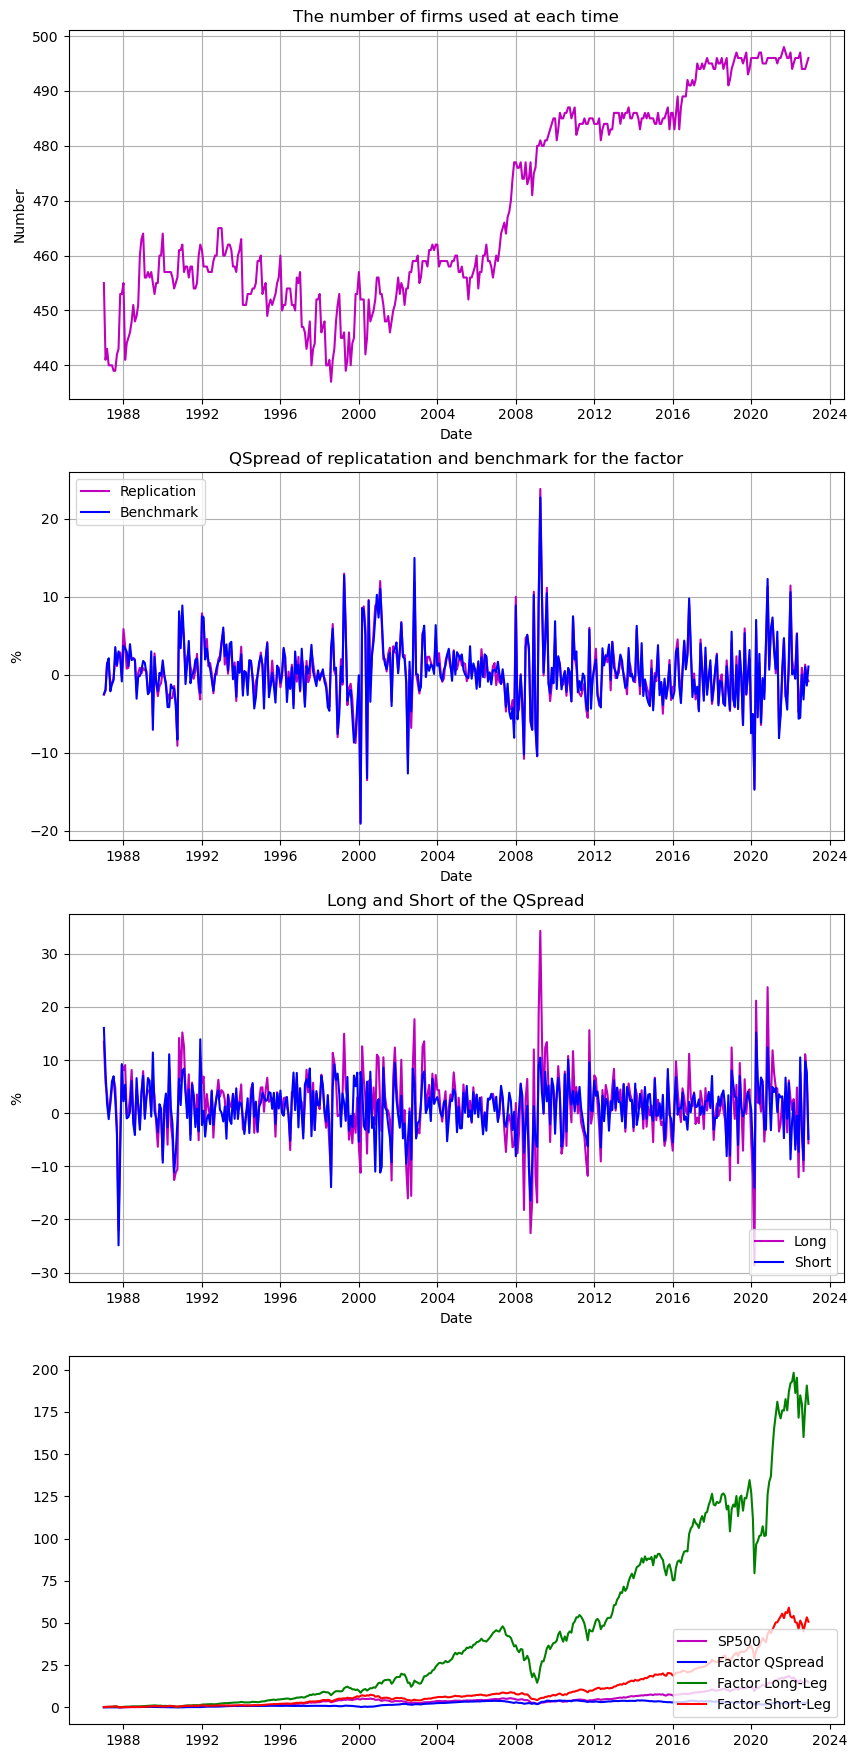

In [9]:
import datetime as dt 
import matplotlib.dates as mdates

# compare whether we could replicate the factor returns from the exsiting Benchmark
benchmark = Benchmark[['Date', 'BP']].copy(deep=True)
benchmark['Date'] = pd.to_datetime(benchmark['Date'].astype(str), format='%Y%m%d') 
benchmark['Date'] = benchmark['Date'].apply(lambda x:x.strftime('%Y%m'))

idx_t_start = Date_Unique.index(int(benchmark['Date'].iloc[0]))
idx_t_end = Date_Unique.index(int(benchmark['Date'].iloc[-1]))

test_factor = BM_Factor_Sort[idx_t_start:idx_t_end+1]
test_Qspread = BM_Qspread[idx_t_start:idx_t_end+1]
test_long = BM_RET_Sort_top[idx_t_start:idx_t_end+1]
test_short = BM_RET_Sort_bottom[idx_t_start:idx_t_end+1]

sp500 = SP500[idx_t_start:idx_t_end+1]

list_nfirms = []
list_long = []
list_short = []

for idx_t in range(len(test_factor)):
    list_nfirms.append(len(test_factor[idx_t]))

for idx_t in range(len(test_long)):
    list_long.append(np.nanmean(test_long[idx_t]['trt1m']))
    list_short.append(np.nanmean(test_short[idx_t]['trt1m']))

ret_sp500 = np.exp(np.cumsum(np.log(1+sp500['ret_sp500'])))-1 # Calculate the cumulative return of the SP500 index
ret_Qspread = np.exp(np.cumsum(np.log(1+np.array(test_Qspread)/100)))-1 # Calculate the cumulative return based on the quantile spread
ret_Long = np.exp(np.cumsum(np.log(1+np.array(list_long)/100)))-1 # Calculate the cumulative return of the long portfolio
ret_Short = np.exp(np.cumsum(np.log(1+np.array(list_short)/100)))-1 # Calculate the cumulative return of the short portfolio


plt.figure(figsize=(10,22))
plt.subplot(4,1,1) # Create a subplot for the number of firms used at each time
xvalues = [dt.datetime.strptime(d,"%Y%m").date() for d
           in np.asarray(benchmark['Date']).astype(str)]
plt.plot(xvalues, list_nfirms, '-m', label="The number of firms used at each time") # Plot the number of firms used at each time period
#plt. legend (loc='upper left')
plt.xlabel('Date')
plt.ylabel('Number')
plt.grid(True) # Enable grid lines for better readability
plt.title('The number of firms used at each time') # Set the title for the first subplot


plt.subplot(4,1,2)
plt.plot(xvalues, test_Qspread, '-m', label="Replication")
plt.plot(xvalues, benchmark['BP'].values, '-b', label="Benchmark")
plt.legend(loc='upper left') 
plt.xlabel('Date')
plt.ylabel('%')
plt.grid(True)
plt.title('QSpread of replicatation and benchmark for the factor')


plt.subplot(4,1,3)
plt.plot(xvalues, list_long, '-m', label="Long")
plt.plot(xvalues, list_short, '-b', label="Short")
plt.legend(loc='lower right')
plt.xlabel('Date')
plt.ylabel('%')
plt.grid(True)
plt.title('Long and Short of the QSpread')


plt.subplot(4,1,4)
plt.plot(xvalues, ret_sp500, '-m', label="SP500")
plt.plot(xvalues, ret_Qspread, '-b', label="Factor QSpread") 
plt.plot(xvalues, ret_Long, '-g', label="Factor Long-Leg")
plt.plot(xvalues, ret_Short, '-r', label="Factor Short-Leg")
plt.legend(loc='lower right')

## Question 1

### Please comment shortly on the performance of the factor BP and compare it to S&P 500. Are their performances comparable? Why or why not? Which contributes to the factor performance more, the long-leg or the short-leg? Can you find any pattern in when (in which time periods) the factor return tends to be poor? (e.g., recession vs. booming periods)

The performance of the factor BP is not very comparable to the S&P 500 because the S&P 500 index benefits from a more diverse portfolio. The long-leg of the BP factor contributes more positively to the overall performance than the short-leg. This is because the long positions generally output a higher return than that compared to the short positions. The BP factor tends to return poor results in times of economic downturn and periods of market uncertainty. This can be seen in the chart of long and short legs where variability is much greater in times of economic downturn, i.e. around 2008. 

# Question 2

Compare the replication to the benchmark

Compute the correlation coefficients for each replicated factor with its benchmark;

Pick the same period of the benchmarket;

The factor to be tested: MV, BM, HL1M

The criteria is a correlation coefficient greater than 0.9 (if the correlation is negative, take the inverse)

In [12]:
from scipy import stats
list_factors = ['MV', 'BM', 'HL1M', 'S&P500']
test_MV_Qspread = MV_Qspread[idx_t_start:idx_t_end+1]
test_BM_Qspread = BM_Qspread[idx_t_start:idx_t_end+1]
test_HL1M_Qspread = HL1M_Qspread[idx_t_start:idx_t_end+1]

list_corr = []
list_corr.append(stats.pearsonr(test_MV_Qspread, Benchmark['LogMktCap'])[0]) # Calculate the Pearson correlation between MV Qspread and Log Market Capitalization
list_corr.append(stats.pearsonr(test_BM_Qspread, Benchmark['BP'])[0]) 
list_corr.append(stats.pearsonr(test_HL1M_Qspread, Benchmark['HL1M'])[0])

# Create a DataFrame to summarize the factors and their corresponding correlation values
df_corr = pd.DataFrame(list(zip(list_factors, list_corr)), columns = ['Factor', 'Corr'])
df_corr

,Factor,Corr
0,MV,0.992169
1,BM,0.973885
2,HL1M,0.971786


# Question 3

In [14]:
list_mean = []
list_std = []
list_sr = []
list_skew = []
list_kurt = []
list_max = []
list_min = []
list_acf1 = []
list_acf12 = []
list_acf24 = []


list_test_factors = [test_MV_Qspread, test_BM_Qspread,
                     test_HL1M_Qspread, sp500['ret_sp500']]

# Calculate various statistics for each test factor
for idx in range(len(list_test_factors)):
    list_mean.append(np.nanmean(list_test_factors[idx]))
    list_std.append(np.nanstd(list_test_factors[idx]))
    list_sr.append(np.sqrt(12)*list_mean[idx]/list_std[idx])
    list_skew.append(stats.skew(list_test_factors[idx]))
    list_kurt.append(stats.kurtosis(list_test_factors[idx]))
    list_max.append(np.nanmax(list_test_factors[idx]))
    list_min.append(np.nanmin(list_test_factors[idx]))
    list_acf1.append(sm.tsa.acf(list_test_factors[idx], nlags=24, fft=False)[1])
    list_acf12.append(sm.tsa.acf(list_test_factors[idx], nlags=24, fft=False)[12])
    list_acf24.append(sm.tsa.acf(list_test_factors[idx], nlags=24, fft=False)[24])

                        
df_table = pd.DataFrame(list(zip(list_mean, list_std, list_sr, list_skew, list_kurt,
                                 list_max, list_min, list_acf1, list_acf12, list_acf24)), 
                        columns =['Mean', 'STD', 'Sharpe Ratio', 'Skewness', 'Kurtosis',
                                  'Max', 'Min', 'ACF1', 'ACF12', 'ACF24'])

df_table.index = list_factors
df_table.T

,MV,BM,HL1M,S&P500
Mean,-0.351353,0.380835,0.792846,0.007414
STD,3.989772,4.006618,3.607656,0.044229
Sharpe Ratio,-0.305060,0.329268,0.761297,0.580661
Skewness,-1.080343,0.309535,1.286733,-0.727039
Kurtosis,9.677470,4.671547,5.748761,2.097639
Max,19.610220,23.844838,20.645740,0.131767
Min,-30.725582,-18.943367,-9.717614,-0.217630
ACF1,0.172911,0.164694,-0.129980,0.023915
ACF12,0.140895,0.014665,-0.010097,0.034097
ACF24,0.064719,-0.022511,0.070606,0.050344


In [15]:
df_test_factor = pd.DataFrame(list(zip(test_MV_Qspread, test_BM_Qspread,
                                       test_HL1M_Qspread, sp500['ret_sp500'])), columns = list_factors)

# Create a DataFrame to hold the Qspread and SP500 return data for each factor to create correlation matrix
pd.DataFrame(np.corrcoef(df_test_factor.T), columns = list_factors,
             index = list_factors)

,MV,BM,HL1M,S&P500
MV,1.000000,-0.731410,-0.469961,-0.328232
BM,-0.731410,1.000000,0.410794,0.187299
HL1M,-0.469961,0.410794,1.000000,0.340829
S&P500,-0.328232,0.187299,0.340829,1.000000


## Question 3

### Please shortly comment on their performance based on those statistics. What are the advantages and disadvantages of those factors? How do they perform compared to S&P 500 index? If you are asked to recommend one investment factor to your portfolio manager, which one will you choose?

#### Advantages and disadvantages for each factor:

The MV factor shows potential for high returns in certain market conditions. A disadvantage is the high volatility and negative mean returns that show that there is potential for underperformance. 

The BM factor shows advantages of positive mean returns and a reasonable positive sharpe ratio. The disadvantage the BM factor shows is the continued potential for substantial risks based on the moderate volatility. Compared to the MV factor however, the risks are not as bad. 

HL1M factor shows promising advantages in that the sharpe ratio is the highest with the best mean positive returns as well. This factor seems to be the best factor by far compared to the other two. Although the results are promising, the risk still remains high with the volatility comparably higher than the S&P500. 

#### Comparison to S&P500:

As the S&P500 is a benchmark that has steady returns and lower risk, it is a great way to compare if the factors are performing well or not. The HL1M factor shows the most promise with the best risk-adjusted returns and seems to outperform the S&P500. BM factor in comparison shows potential in achieving greater returns than both the S&P500 and the HL1M factor. Finally, the MV factor underperforms comparing to all the factors and the index.

#### Recommendation:

For the best recommendation for the factor to use, I would recommend to imploy the HL1M factor because of the highest sharpe ratio and positive skewness that represents high upside with lower risk.

# Question 4

In [29]:
list_mean = []
list_tstats = []
list_pvalue = []

# Calculate the mean, t-statistics, and p-values for each test factor against a null hypothesis mean of 0
for idx in range(len(list_test_factors)):
    list_mean.append(np.nanmean(list_test_factors[idx]))
    
    # Perform a one-sample t-test to calculate the t-statistic for the test factor
    list_tstats.append(stats.ttest_1samp(list_test_factors[idx], 0)[0]) 
    list_pvalue.append(stats.ttest_1samp(list_test_factors[idx], 0)[1])

                                           
df_table_test = pd.DataFrame(list(zip(list_mean, list_tstats, list_pvalue)),
                             columns =['Mean', 'T Stats', 'p-Value'])

df_table_test.index = list_factors # Set the index of the DataFrame to the list of factor names
df_table_test

,Mean,T Stats,p-Value
MV,-0.351353,-1.828242,0.068204
BM,0.380835,1.973318,0.049098
HL1M,0.792846,4.562493,0.000007
S&P500,0.007414,3.479930,0.000553


## Question 4

### Conduct a hypothesis test for each factor you constructed. Using the time-series of the factor returns (QSpread) and a t-test to show whether the mean of each factor is significantly different from zero. Please highlight those factors with significant QSpread. Are they consistent with your expectation? (Note that for this question, use the whole sample period: 197001 to 202212)

From the hypothesis test that was done above, it can be seen that the BM, HL1M, and S&P500 factors are all significant at the 5% significance level. The only factor not statistically significant is the MV factor but does not seem to be too far off. Based off the results, we can conclude that the statistical significance is inline with expectations that value and momentum stategies generally yield positive returns and are different from zero in mean. The statistical significance for the S&P500 is also within expectations because of the role of it being a benchmark. 